# Exemplo Prático: A Perceptron

Vamos a um exemplo prático para aprofundarmos os conhecimentos.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import Perceptron

## Gerando o conjunto de dados aleatoriamente

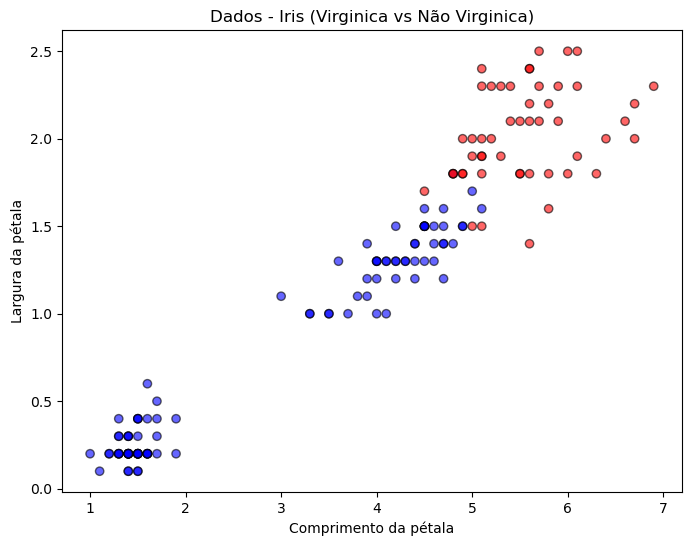

In [2]:
iris = datasets.load_iris()

X = iris["data"][:, 2:4]  # comprimento e largura da pétala
y = (iris["target"] == 2).astype(int)

plt.figure(figsize=(8, 6))
plt.scatter(
    X[:, 0], 
    X[:, 1], 
    c=y,
    cmap="bwr", 
    alpha=0.6, 
    edgecolors="k"
)
plt.xlabel("Comprimento da pétala")
plt.ylabel("Largura da pétala")
plt.title("Dados - Iris (Virginica vs Não Virginica)")
plt.show()

## Perceptron

In [ ]:
# 1. inicialização: parâmetros iniciais
m = X.shape[0]
weight1, weight2 = np.random.randn(2) # inicialização aleatória
bias = np.random.randn()
eta = 0.01
n_iterations = 1000

for iteration in range(n_iterations):
    errors = 0
    for example in range(m):

        # valores atuais
        x1 = X[example][0]
        x2 = X[example][1]
        yi = y[example]

        # soma ponderada
        z = bias + x1 * weight1 + x2 * weight2
        y_hat = 1 if z > 0 else 0

        # atualização dos pesos: regra de aprendizagem
        error = yi - y_hat
        if error != 0:
            errors += 1
        weight1 = weight1 + eta * error * x1
        weight2 = weight2 + eta * error * x2
        bias = bias + eta * error
    
    # printar a evolução dos erros
    print(f"Época {iteration + 1}: erros = {errors}")

print(f"\nweight1: {weight1}")
print(f"weight2: {weight2}")
print(f"bias: {bias}")

Época 1: erros = 68
Época 2: erros = 26
Época 3: erros = 19
Época 4: erros = 15
Época 5: erros = 13
Época 6: erros = 12
Época 7: erros = 11
Época 8: erros = 11
Época 9: erros = 8
Época 10: erros = 7
Época 11: erros = 5
Época 12: erros = 5
Época 13: erros = 5
Época 14: erros = 4
Época 15: erros = 7
Época 16: erros = 6
Época 17: erros = 4
Época 18: erros = 4
Época 19: erros = 5
Época 20: erros = 4
Época 21: erros = 4
Época 22: erros = 5
Época 23: erros = 4
Época 24: erros = 3
Época 25: erros = 4
Época 26: erros = 4
Época 27: erros = 3
Época 28: erros = 4
Época 29: erros = 4
Época 30: erros = 5
Época 31: erros = 4
Época 32: erros = 3
Época 33: erros = 4
Época 34: erros = 4
Época 35: erros = 3
Época 36: erros = 4
Época 37: erros = 4
Época 38: erros = 3
Época 39: erros = 4
Época 40: erros = 3
Época 41: erros = 2
Época 42: erros = 2
Época 43: erros = 4
Época 44: erros = 3
Época 45: erros = 2
Época 46: erros = 4
Época 47: erros = 3
Época 48: erros = 2
Época 49: erros = 2
Época 50: erros = 4
É

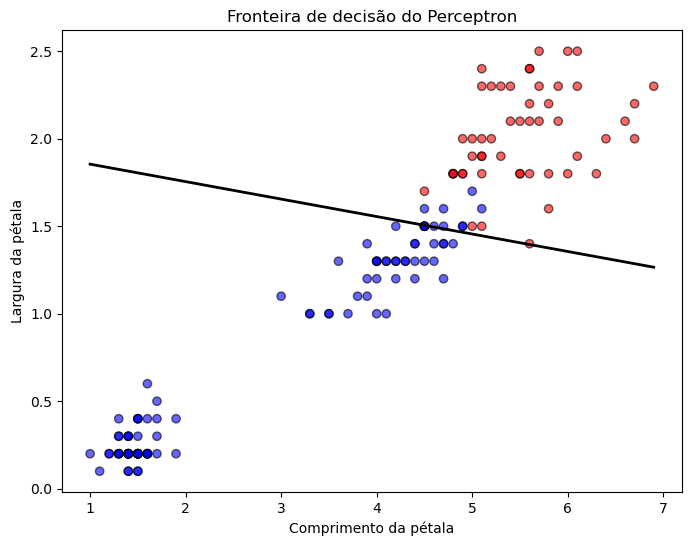

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", alpha=0.6, edgecolors="k")

# linha de decisão: w1*x1 + w2*x2 + b = 0
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = -(bias + weight1*x1) / weight2

plt.plot(x1, x2, color="black", linewidth=2)
plt.xlabel("Comprimento da pétala")
plt.ylabel("Largura da pétala")
plt.title("Fronteira de decisão do Perceptron")
plt.show()

## Exemplo prático: usando a scikit-learn

Fizemos a implementação da perceptron manualmente, mas podemos utilizá-la diretamente com a scikit-learn.

In [6]:
# instanciando a classe Perceptron
clf = Perceptron()

# método fit para treinar o modelo
clf.fit(X, y)

# método para obter a acurácia atingida
clf.score(X, y)

0.96

Esse é o classificador perceptron. Essa classe é um wrapper *SGDClassifier* que envolve a fixação dos parâmetros *loss* e *learning_rate* da seguinte forma:

*SGDClassifier(loss="perceptron", learning_rate="constant")*.

Agora vamos obter o gráfico da reta, como fizemos na implementação acima para comparar ambas.

weight1: 1.5999999999999845
weight2: 28.799999999999983
bias: -54.0


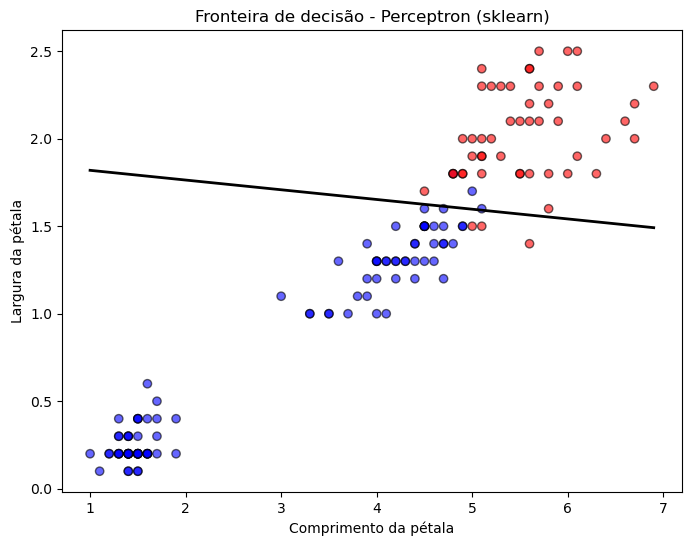

In [8]:
# obtendo os pesos do modelo
w = clf.coef_[0]
b = clf.intercept_[0]

print("weight1:", w[0])
print("weight2:", w[1])
print("bias:", b)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", alpha=0.6, edgecolors="k")
# fronteira: w1*x1 + w2*x2 + b = 0
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = -(b + w[0]*x1) / w[1]
plt.plot(x1, x2, color="black", linewidth=2)
plt.xlabel("Comprimento da pétala")
plt.ylabel("Largura da pétala")
plt.title("Fronteira de decisão - Perceptron (sklearn)")
plt.show()

Vemos que as duas implementações obtiveram retas bem parecidas.